In [1]:
!pip install -q transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import pipeline
from sklearn.metrics import accuracy_score

## Data Loading

I first load the dataset and perform a quick inspection before cleaning or modeling.

In [4]:
df = pd.read_csv("/content/Womens Clothing E-Commerce Reviews.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
df.shape

(23486, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [7]:
df.dtypes

,0
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,object
Review Text,object
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,object
Department Name,object


In [8]:
df.describe(include="all")

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
count,23486.000000,23486.000000,23486.000000,19676,22641,23486.000000,23486.000000,23486.000000,23472,23472,23472
unique,NaN,NaN,NaN,13993,22634,NaN,NaN,NaN,3,6,20
top,NaN,NaN,NaN,Love it!,Perfect fit and i've gotten so many compliment...,NaN,NaN,NaN,General,Tops,Dresses
freq,NaN,NaN,NaN,136,3,NaN,NaN,NaN,13850,10468,6319
mean,11742.500000,918.118709,43.198544,NaN,NaN,4.196032,0.822362,2.535936,NaN,NaN,NaN
std,6779.968547,203.298980,12.279544,NaN,NaN,1.110031,0.382216,5.702202,NaN,NaN,NaN
min,0.000000,0.000000,18.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,5871.250000,861.000000,34.000000,NaN,NaN,4.000000,1.000000,0.000000,NaN,NaN,NaN
50%,11742.500000,936.000000,41.000000,NaN,NaN,5.000000,1.000000,1.000000,NaN,NaN,NaN
75%,17613.750000,1078.000000,52.000000,NaN,NaN,5.000000,1.000000,3.000000,NaN,NaN,NaN


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [10]:
df["Recommended IND"].value_counts()

,count
Recommended IND,
1,19314
0,4172


Observation: The dataset contains clothing reviews with customer information, review text, ratings, and recommendation labels. The target column is Recommended IND, where 1 means recommended and 0 means not recommended.

In [15]:
df["Recommended IND"].value_counts(normalize=True)

,proportion
Recommended IND,
1,0.822362
0,0.177638


In [11]:
df = df[["Review Text", "Recommended IND"]]

df.head()

,Review Text,Recommended IND
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


## Initial Data Inspection

I checked the number of rows and columns, data types, descriptive statistics, missing values, and class distribution.

`Review Text` contains the customer-written review and `Recommended IND` is the binary target.

The target has two classes:
- 1 = recommended / positive
- 0 = not recommended / negative

The class counts also show whether the dataset is balanced or whether one class appears more frequently.

## Data Cleaning

For this task I only need the review text and recommendation label.

I will remove rows without review text and check duplicate records before and after cleaning.

In [16]:
df = df[
    [
        "Review Text",
        "Recommended IND"
    ]
]

df.columns = [
    "text",
    "label"
]

df.head()

,text,label
0,Absolutely wonderful - silky and sexy and comf...,1
1,Love this dress! it's sooo pretty. i happene...,1
2,I had such high hopes for this dress and reall...,0
3,"I love, love, love this jumpsuit. it's fun, fl...",1
4,This shirt is very flattering to all due to th...,1


In [17]:
df.isnull().sum()

,0
text,845
label,0


In [18]:
df = df.dropna(
    subset=["text"]
).reset_index(drop=True)

In [19]:
df.isnull().sum()

,0
text,0
label,0


### Missing Values

Missing values were checked again after selecting the final columns.

Rows without review text are removed because the Transformer cannot perform sentiment analysis on empty text. No imputation is needed for the review text.

In [20]:
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(7)

In [21]:
df = df.drop_duplicates().reset_index(drop=True)

In [22]:
df.duplicated().sum()

np.int64(0)

### Duplicate Handling

Duplicate review-label records were checked and removed so that repeated reviews do not influence the analysis more than once.

The duplicate count is checked again after cleaning to verify that the duplicates were removed.

## Feature Engineering

I create two simple text-based features for EDA:

- `text_length`: number of characters in a review.
- `word_count`: number of words in a review.

These features may help distinguish positive and negative reviews because the two groups may differ in how much customers write.

In [23]:
df["text_length"] = df["text"].str.len()

df["word_count"] = df["text"].str.split().str.len()

df.head()

,text,label,text_length,word_count
0,Absolutely wonderful - silky and sexy and comf...,1,53,8
1,Love this dress! it's sooo pretty. i happene...,1,303,62
2,I had such high hopes for this dress and reall...,0,500,98
3,"I love, love, love this jumpsuit. it's fun, fl...",1,124,22
4,This shirt is very flattering to all due to th...,1,192,36


In [24]:
df[
    [
        "text_length",
        "word_count"
    ]
].describe()

,text_length,word_count
count,22634.000000,22634.000000
mean,308.698065,60.199214
std,143.932380,28.533191
min,9.000000,2.000000
25%,186.000000,36.000000
50%,301.000000,59.000000
75%,458.750000,88.000000
max,508.000000,115.000000


## Outlier Detection

I use the IQR method on review length to identify unusually long reviews.

Very long reviews are not automatically removed because they can still be legitimate customer reviews rather than data-entry errors.

In [25]:
Q1 = df["text_length"].quantile(0.25)

Q3 = df["text_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [26]:
outliers = df[
    (df["text_length"] < lower_bound) |
    (df["text_length"] > upper_bound)
]

outliers[
    ["text", "text_length"]
].head()

,text,text_length


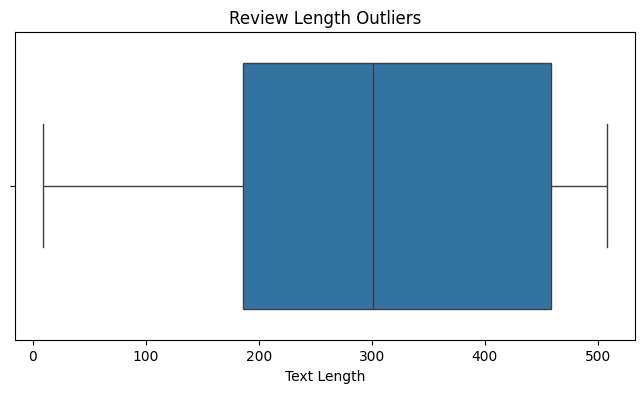

In [27]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["text_length"]
)

plt.title("Review Length Outliers")
plt.xlabel("Text Length")

plt.show()

### Outlier Decision

The IQR rule identifies some reviews that are much longer than most reviews.

I keep these reviews because long customer reviews are valid observations and are not clearly incorrect values. Removing them could discard useful sentiment information.

## Exploratory Data Analysis

I use multiple visualizations to understand class balance, review length, group differences, and relationships between the engineered features.

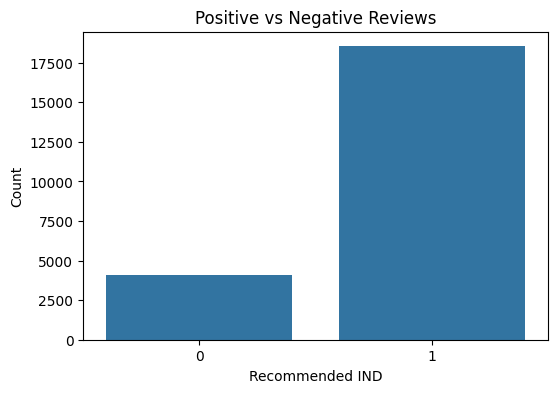

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Positive vs Negative Reviews")
plt.xlabel("Recommended IND")
plt.ylabel("Count")

plt.show()

### Observation

This chart shows the class balance between recommended and non-recommended reviews.

If class 1 is much larger than class 0, the dataset contains more positive reviews than negative reviews.

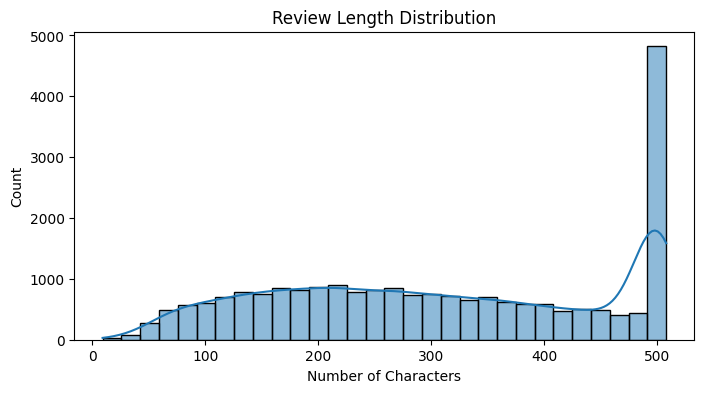

In [29]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df["text_length"],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Characters")

plt.show()

### Observation

Most customer reviews fall within a common length range, while a smaller number of reviews are considerably longer.

This explains the right tail seen in the review-length distribution.

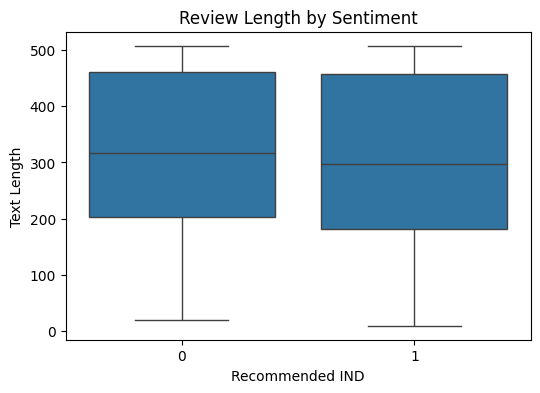

In [30]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="label",
    y="text_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Recommended IND")
plt.ylabel("Text Length")

plt.show()

### Observation

This plot compares review length for positive and negative reviews.

Any visible difference between the groups suggests that review length may contain useful information about customer sentiment.

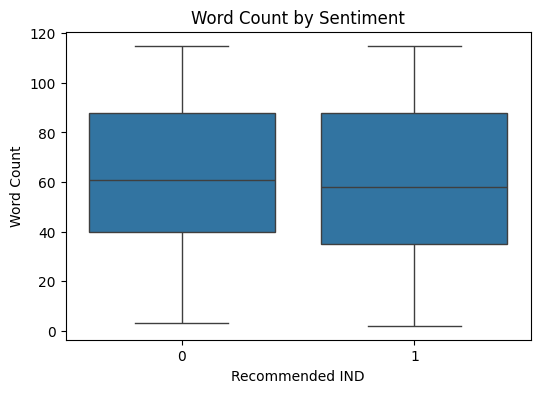

In [31]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="label",
    y="word_count"
)

plt.title("Word Count by Sentiment")
plt.xlabel("Recommended IND")
plt.ylabel("Word Count")

plt.show()

### Observation

This chart compares the number of words used in positive and negative reviews.

Differences between the groups support the idea that word count can be a useful engineered feature.

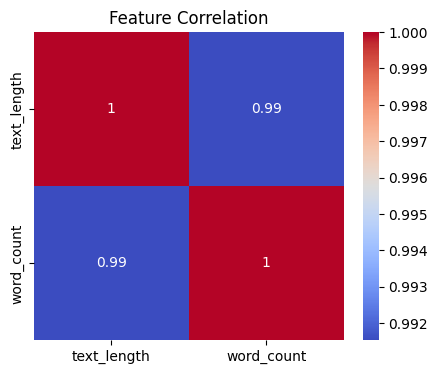

In [32]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    df[
        [
            "text_length",
            "word_count"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

### Observation

Text length and word count are positively correlated because reviews containing more words generally contain more characters as well.

In [33]:
df.groupby("label")[
    [
        "text_length",
        "word_count"
    ]
].mean()

,text_length,word_count
label,,
0,318.289268,61.993659
1,306.576346,59.802255


In [34]:
df["label"].value_counts()

,count
label,
1,18534
0,4100


In [35]:
df[
    [
        "text_length",
        "word_count"
    ]
].describe()

,text_length,word_count
count,22634.000000,22634.000000
mean,308.698065,60.199214
std,143.932380,28.533191
min,9.000000,2.000000
25%,186.000000,36.000000
50%,301.000000,59.000000
75%,458.750000,88.000000
max,508.000000,115.000000


## Five Key Insights

1. The target contains two groups: recommended/positive reviews and non-recommended/negative reviews.

2. Missing review text was checked and removed before analysis because empty text cannot be processed by the Transformer.

3. Duplicate review records were checked and removed so repeated reviews would not influence the results more than once.

4. Review length and word count vary across customers, and the label-wise boxplots show whether positive and negative reviewers tend to write differently.

5. Text length and word count have a strong positive relationship because reviews containing more words normally also contain more characters.

# Pretrained Transformer Sentiment Model

Instead of training a new neural network, I use Hugging Face's default pretrained sentiment-analysis pipeline.

The model already understands general positive and negative sentiment and can be used directly for inference.

In [36]:
df["true_label"] = df["label"].map({
    1: "POSITIVE",
    0: "NEGATIVE"
})

df[
    [
        "text",
        "label",
        "true_label"
    ]
].head()

,text,label,true_label
0,Absolutely wonderful - silky and sexy and comf...,1,POSITIVE
1,Love this dress! it's sooo pretty. i happene...,1,POSITIVE
2,I had such high hopes for this dress and reall...,0,NEGATIVE
3,"I love, love, love this jumpsuit. it's fun, fl...",1,POSITIVE
4,This shirt is very flattering to all due to th...,1,POSITIVE


In [37]:
sample = df.sample(
    n=150,
    random_state=42
).reset_index(drop=True)

sample.shape

(150, 5)

## Random Sample

I randomly select 150 reviews, which satisfies the required sample size of 100–200 rows.

`random_state=42` makes the same sample reproducible if the notebook is run again.

In [38]:
classifier = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

## Pretrained Pipeline

`pipeline("sentiment-analysis")` automatically downloads and loads a ready-made sentiment classification model.

No model training or GPU is required for this task.

In [39]:
predictions = classifier(
    sample["text"].tolist(),
    truncation=True
)

`truncation=True` safely shortens any review that exceeds the Transformer's maximum input length.

In [40]:
sample["predicted_label"] = [
    result["label"]
    for result in predictions
]

sample.head()

,text,label,text_length,word_count,true_label,predicted_label
0,This top is really pretty and nice quality. ru...,1,144,29,POSITIVE,POSITIVE
1,I was so excited to splurge on a mara hoffman ...,0,418,81,NEGATIVE,NEGATIVE
2,Got so many complements! really comfy but runs...,1,106,21,POSITIVE,POSITIVE
3,I've ordered a pair of these from the catalog ...,1,239,46,POSITIVE,POSITIVE
4,The dress is very beautiful and looks expensiv...,1,196,36,POSITIVE,POSITIVE


In [41]:
sample["correct"] = (
    sample["true_label"]
    ==
    sample["predicted_label"]
)

In [42]:
match_accuracy = sample["correct"].mean()

match_accuracy

np.float64(0.8733333333333333)

## Transformer Accuracy

The match score represents the fraction of sampled reviews where the Transformer's POSITIVE/NEGATIVE prediction matches the dataset's mapped label.

For example, a value of 0.80 means that 80% of the sampled predictions matched the dataset labels.

In [43]:
sample[
    [
        "text",
        "true_label",
        "predicted_label"
    ]
].head(5)

,text,true_label,predicted_label
0,This top is really pretty and nice quality. ru...,POSITIVE,POSITIVE
1,I was so excited to splurge on a mara hoffman ...,NEGATIVE,NEGATIVE
2,Got so many complements! really comfy but runs...,POSITIVE,POSITIVE
3,I've ordered a pair of these from the catalog ...,POSITIVE,POSITIVE
4,The dress is very beautiful and looks expensiv...,POSITIVE,POSITIVE


In [44]:
sample["confidence"] = [
    result["score"]
    for result in predictions
]

sample[
    [
        "text",
        "true_label",
        "predicted_label",
        "confidence"
    ]
].head(5)

,text,true_label,predicted_label,confidence
0,This top is really pretty and nice quality. ru...,POSITIVE,POSITIVE,0.999781
1,I was so excited to splurge on a mara hoffman ...,NEGATIVE,NEGATIVE,0.990193
2,Got so many complements! really comfy but runs...,POSITIVE,POSITIVE,0.988432
3,I've ordered a pair of these from the catalog ...,POSITIVE,POSITIVE,0.999636
4,The dress is very beautiful and looks expensiv...,POSITIVE,POSITIVE,0.965359


## What Attention Does

Attention allows a Transformer to consider how different words in the review relate to each other and to give more importance to words that matter for the meaning.

Bag-of-Words mainly counts which words appear and does not understand word order or relationships between words.

## Conclusion

The dataset was inspected, cleaned, and explored before sentiment prediction.

Two text-based features were engineered, outliers were checked using IQR, and multiple EDA plots were used to understand the data.

A random sample of 150 reviews was then classified using a pretrained Transformer sentiment pipeline, and its POSITIVE/NEGATIVE predictions were compared with the dataset's mapped recommendation labels.

The final match score shows how well the pretrained model's general sentiment understanding agrees with the Women's Clothing recommendation labels.